In [1]:
# Basic parameters
building = 0            # Which house to run the models for
hours = 24              # How many hours ahead

timings = {}            # Set up a dictionary for timings
best_epoch = {}         # Set up a dictionary to track best epoch

# Setup

In [2]:
# All imports and custom functions
import torch
import pandas as pd
import numpy as np
import time
import os

import src.data.dataprep as prep
import src.data.featurisation as features

from src.Lstm import LSTM
from src.lstmopt import CVXLayer
from src.dual_lstmopt import LSTMOPT_DUAL

from src.training.training import  Training as Training
from src.training.training_opt_dual import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.Tensors as tensor

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('./data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h')
DHI = np.load('./data/DHI_fcsts/DHI_fcst.npy')
nl_data['direct_rad'] = DHI

# Data Augmentation

In [4]:
# Add hourly sinusoidal patterns as features
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]

In [5]:
# Include a battery based on Weniger et al. “Sizing of Residential PV Battery Systems,”
battery_capacity = round(nl_data['load'].resample('YE').sum().max() * 1.1 / 1000,1)

# The C-rate comes from Olivieri and McConky “Optimization of residential battery energy storage system scheduling for cost and emissions reductions,”
max_charge = battery_capacity/2.7
max_discharge = max_charge

In [6]:
# Set up the PV-B system
pvb_system = pvb.PV_battery(nl_data, building, battery_capacity, max_charge, max_discharge, self_consumption=False)

In [7]:
# Hyperparameters
epochs = 200
layers = 3
neurons = 200
train_test_split = 0.6
dropout = 0.5

lags = 24           # The number of lags for this first timeslot: the 24 previous hours
forecast_gap = 0    # The gap after every forecast which is 0 when we need to forecast 24 hours

# PV LSTM model

In [8]:
# Parameters
past_features_pv = ['solar_energy']
future_features_pv = ['direct_rad', 'hour_sin','hour_cos']
opt_features_pv = ['load','offtake','injection']

opt_future_features_pv = future_features_pv + opt_features_pv
features_pv = len(past_features_pv) + len(future_features_pv)

# And for the baseline LSTM model
domain_min_pv = [min(nl_data['solar_energy'][:676*24+24]), # past: solar energy
                   min(nl_data['direct_rad'][:676*24+24]),   # future: direct radiation
                   -1,-1,                                    # future: hour sin + cos
                   min(nl_data['solar_energy'][:676*24+24])] # target: solar energy

domain_max_pv = [max(nl_data['solar_energy'][:676*24+24]), # past: solar energy
                   max(nl_data['direct_rad'][:676*24+24]),   # future: direct radiation
                   1,1,                                      # future: hour sin + cos
                   max(nl_data['solar_energy'][:676*24+24])] # target: solar energy

## Tensors

In [9]:
# Tensors for training
nl_tensors = tensor.Tensors(pvb_system.house,                       # Our data
                            ['solar_energy'],                         # The target variable name
                            past_features_pv,                          # Past features (see section Parameters)
                            future_features_pv,                        # Future features (see section Parameters)
                            lags,                                   # The number of lags we use for past features
                            hours,                                  # The number of time steps we have to forecast
                            forecast_gap=forecast_gap,              # If there is a gap between the timing of the forecast and forecast period
                            train_test_split=train_test_split,      # The split in train and test set
                            domain_min=domain_min_pv,             # In case we have domain knowledge on minima...
                            domain_max=domain_max_pv)             # ...and maxima

# Create the tensors
X_train_pv, X_test_pv, y_train_pv, y_test_pv, scale_pv = nl_tensors.create_tensor()


## Model

In [10]:
# Create an LSTM model
lstm_pv = LSTM(features_pv,         # Number of features
            neurons,                # Number of neurons
            layers,                 # Number of layers
            hours,                  # The output size
            dropout                 # The dropout percentage
            ).to(device)

In [11]:
trainer_base = Training(lstm_pv,                                       # Load the model
                        X_train_pv, y_train_pv.squeeze(-1),                 # Specify the train set
                        X_test_pv, y_test_pv.squeeze(-1),                   # Specify The test set
                        epochs,                                     # The number of epochs to train for
                        learning_rate=0.0005)                       # The learning ra te

start = time.time()                                                 # We keep track of time to compare to a VOF model
state_dicts_lstm_pv, best_lstm_pv = trainer_base.fit(verbose=0)           # Start training
timings['LSTM'] = time.time() - start                               # Stop timing after training
best_epoch['LSTM'] = best_lstm_pv                                      # Keep track of the best epoch
lstm_pv.load_state_dict(state_dicts_lstm_pv[best_lstm_pv])                   # Load the best state dictionary

Best Epoch: 192


<All keys matched successfully>

# Load LSTM model

In [12]:
# Parameters
past_features_load = ['load']
future_features_load = ['hour_sin','hour_cos']
opt_features_load = ['load','offtake','injection']

opt_future_features_load = future_features_load + opt_features_load
features_load = len(past_features_load) + len(future_features_load)

# And for the baseline LSTM model
domain_min_load = [min(nl_data['load'][:676*24+24]),       # past: solar energy
                   -1,-1,                                       # future: hour sin + cos
                   min(nl_data['load'][:676*24+24])]            # target: solar energy

domain_max_load = [max(nl_data['load'][:676*24+24]),       # past: solar energy
                   1,1,                                         # future: hour sin + cos
                   max(nl_data['load'][:676*24+24])]            # target: solar energy

In [13]:
# Tensors for training
nl_tensors_load = tensor.Tensors(pvb_system.house,                       # Our data
                            ['load'],                         # The target variable name
                            past_features_load,                          # Past features (see section Parameters)
                            future_features_load,                        # Future features (see section Parameters)
                            lags,                                   # The number of lags we use for past features
                            hours,                                  # The number of time steps we have to forecast
                            forecast_gap=forecast_gap,              # If there is a gap between the timing of the forecast and forecast period
                            train_test_split=train_test_split,      # The split in train and test set
                            domain_min=domain_min_load,             # In case we have domain knowledge on minima...
                            domain_max=domain_max_load)             # ...and maxima

# Create the tensors
X_train_load, X_test_load, y_train_load, y_test_load, scale_load = nl_tensors_load.create_tensor()

In [14]:
# Create an LSTM model
lstm_load = LSTM(features_load,               # Number of features
            neurons,                # Number of neurons
            layers,                 # Number of layers
            hours,                  # The output size
            dropout                 # The dropout percentage
            ).to(device)

In [15]:
trainer_base = Training(lstm_load,                                  # Load the model
                        X_train_load, y_train_load.squeeze(-1),     # Specify the train set
                        X_test_load, y_test_load.squeeze(-1),       # Specify The test set
                        epochs,                                     # The number of epochs to train for
                        learning_rate=0.0005)                       # The learning ra te

start = time.time()                                                 # We keep track of time to compare to a VOF model
state_dicts_lstm_load, best_lstm_load = trainer_base.fit(verbose=0) # Start training
timings['LSTM'] = time.time() - start                               # Stop timing after training
best_epoch['LSTM'] = best_lstm_load                                 # Keep track of the best epoch
lstm_load.load_state_dict(state_dicts_lstm_load[best_lstm_load])    # Load the best state dictionary

Best Epoch: 18


<All keys matched successfully>

# LSTM-CVX model

Next we make a model which integrates the optimization and the forecast. For this we need all parameters to do the optimization.

In [16]:
# Create the current optimization problem and obtain all parameters
problem, variables, parameters = pvb_system.create_optimization_problem(hours)

# Create the post-forecast optimization problem which we need to calculate the regret
problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(hours)

# Create CVX layers (or just use a cvxpy solver, the result should be the same)
cvx_real = CVXLayer(problem, parameters, variables)
cvx_post = CVXLayer(problem_post, parameters_post, variables_post)

## Tensors

We create tensors for the CVX neural network. We can use the data in our dataframe for this but we need 2 additional steps as well:
1. We need the initial battery states from the previous timestep
2. We need the daily cost of optimizing under a perfect forecast to train the neural network on the 'regret', the difference in costs using perfect knowledge and using a forecast

In [17]:
# Parameters
past_features = ['solar_energy', 'load']
future_features = ['direct_rad', 'hour_sin','hour_cos']
opt_features = ['offtake','injection']

opt_future_features = future_features + opt_features
features = len(past_features) + len(future_features)

# Create domain_min and domain_max for the opt models
domain_min = [min(nl_data['solar_energy'][:676*24+24]),         # past: solar energy
              min(nl_data['load'][:676*24+24]),                 # past: load
              min(nl_data['direct_rad'][:676*24+24]),           # future: direct radiation
              -1,-1,                                            # future: hour sin + cos
              0,0,                                              # future: optimization parameters
              min(nl_data['solar_energy'][:676*24+24]),         # target: load
              min(nl_data['load'][:676*24+24])]                 # target: solar energy

domain_max = [max(nl_data['solar_energy'][:676*24+24]),         # past: solar energy
              max(nl_data['load'][:676*24+24]),                 # past: load
              max(nl_data['direct_rad'][:676*24+24]),           # future: direct radiation
              1,1,                                              # future: hour sin + cos
              1,1,                                              # future: optimization parameters
              max(nl_data['solar_energy'][:676*24+24]),         # target: load
              max(nl_data['load'][:676*24+24])]                 # target: solar energy

### Baseline tensors

In [18]:
# Tensors for training, identical to before but now we include the optimization parameters
nl_opt_tensors = tensor.Tensors(pvb_system.house,                       # Our data
                                ['solar_energy', 'load'],               # The target variable name
                                past_features,                          # Past features (see section Parameters)
                                opt_future_features,                    # Future features (see section Parameters)
                                lags,                                   # The number of lags we use for past features
                                hours,                                  # The number of time steps we have to forecast
                                forecast_gap=forecast_gap,              # If there is a gap between the timing of the forecast and forecast
                                train_test_split=train_test_split,      # The split in train and test set
                                domain_min=domain_min,                  # In case we have domain knowledge on minima...
                                domain_max=domain_max)                  # ...and maxima

X_train_opt, X_test_opt, y_train_opt, y_test_opt, scalers_opt = nl_opt_tensors.create_tensor()     # Obtain the tensors (we only need new X tensors, the Y is identical)

### Initial battery states

Now we use the initial battery states which we obtained earlier from running the previous optimization programs

In [19]:
# Create an empty tensor to add to the X tensors
initial_bat_tensor_lstm_cvx_train = torch.zeros([X_train_opt.shape[0],lags,1])
initial_bat_tensor_lstm_cvx_test = torch.zeros([X_test_opt.shape[0],lags,1])


# If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity, as we also make sure that the end
# state of the battery from the previous day is 50%
initial_bat_tensor_lstm_cvx_train[:,-1,:] = battery_capacity * 0.5
initial_bat_tensor_lstm_cvx_test[:,-1,:] = battery_capacity * 0.5


# Add the initial battery states to the tensors
X_train_lstm_cvx = torch.concat([X_train_opt, initial_bat_tensor_lstm_cvx_train],dim=-1)
X_test_lstm_cvx = torch.concat([X_test_opt, initial_bat_tensor_lstm_cvx_test],dim=-1)

### Regret

Now we need to have optimal solutions given correct PV values in order to obtain the "regret" for training the E2E forecaster. These will be added to the Y tensor. So the Y tensor contains both the true PV values and the true cost values.

1. We solve the optimization

In [20]:
# get the optimal parameters for the train set
lstm_cvx_vars_train = cvx_real(rescale(y_train_opt[:,-hours:,0],scalers_opt[-2]),            # PV
                          rescale(y_train_opt[:,-hours:,1],scalers_opt[-1]),
                          X_train_lstm_cvx[:,-hours:,-3],                    # Off-take cost
                          X_train_lstm_cvx[:,-hours:,-2],                    # Injection cost
                          X_train_lstm_cvx[:,-1,-1])                         # Battery state

lstm_cvx_vars_test = cvx_real(rescale(y_test_opt[:,-hours:,0],scalers_opt[-2]),            # PV
                          rescale(y_test_opt[:,-hours:,1],scalers_opt[-1]),
                          X_test_lstm_cvx[:,-hours:,-3],
                          X_test_lstm_cvx[:,-hours:,-2],
                          X_test_lstm_cvx[:,-1,-1])

# CURRENT WORK

2. We calculate the cost on a daily basis

In [21]:
# Obtain the true cost values
solution_lstm_cvx_train = (torch.bmm(lstm_cvx_vars_train[0].unsqueeze(1), X_train_lstm_cvx[:, -hours:, -3].unsqueeze(-1)) -
                           torch.bmm(lstm_cvx_vars_train[1].unsqueeze(1), X_train_lstm_cvx[:, -hours:, -2].unsqueeze(-1)))

# Identical as above
solution_lstm_cvx_test = (torch.bmm(lstm_cvx_vars_test[0].unsqueeze(1), X_test_lstm_cvx[:, -hours:, -3].unsqueeze(-1)) -
                          torch.bmm(lstm_cvx_vars_test[1].unsqueeze(1), X_test_lstm_cvx[:, -hours:, -2].unsqueeze(-1)))

3. We plug these costs as solutions in our y tensors

In [22]:
y_train_lstm_cvx = y_train_opt
y_test_lstm_cvx = y_test_opt

# Step 1: Pad solution_cvx_train with zeros to make it (676, 24, 1)
solution_lstm_cvx_train_padded = torch.zeros((solution_lstm_cvx_train.shape[0], hours, 1))
solution_lstm_cvx_test_padded = torch.zeros((solution_lstm_cvx_test.shape[0], hours, 1))

solution_lstm_cvx_train_padded[:, -1, :] = solution_lstm_cvx_train.squeeze(2)  # fill in the first time step
solution_lstm_cvx_test_padded[:, -1, :] = solution_lstm_cvx_test.squeeze(2)  # fill in the first time step

# Step 2: Concatenate along the last dimension
y_train_lstm_cvx = torch.cat((y_train_lstm_cvx, solution_lstm_cvx_train_padded), dim=2)
y_test_lstm_cvx = torch.cat((y_test_lstm_cvx, solution_lstm_cvx_test_padded), dim=2)

## Models

In [23]:
# LSTM to CVX model (identical to CVX model but with pre-loaded state dictionary)
lstm_cvx_opt = LSTMOPT_DUAL(features_pv,
                            features_load,
                            neurons,
                            layers,
                            hours,
                            0.5,
                            problem,
                            parameters,
                            variables,
                            scale_pv[0],
                            scale_load[0]).to(device)

In [24]:
lstm_cvx_opt.lstm_1.load_state_dict(lstm_pv.lstm.state_dict())
lstm_cvx_opt.linear_1.load_state_dict(lstm_pv.linear.state_dict())

lstm_cvx_opt.lstm_2.load_state_dict(lstm_load.lstm.state_dict())
lstm_cvx_opt.linear_2.load_state_dict(lstm_load.linear.state_dict())

<All keys matched successfully>

In [25]:
# LSTM to CVX model
trainer_2 = Training_opt(lstm_cvx_opt,
                        cvx_post,
                        X_train_lstm_cvx,
                        y_train_lstm_cvx,
                        X_test_lstm_cvx,
                        y_test_lstm_cvx,
                        scalers_opt[0:2],
                        epochs-100,
                        hours,
                        battery_capacity,
                        learning_rate=0.0001,
                        lr_decay=None)

Step 0:
Average train loss: 0.1089 | Average test loss: 0.1003
   MSE PV: 0.0058 | 0.0084
   MSE LOAD: 0.0103 | 0.0113

Step 5:
Average train loss: 0.0571 | Average test loss: 0.0803
   MSE PV: 0.0125 | 0.0154
   MSE LOAD: 0.0182 | 0.0143

Step 10:
Average train loss: 0.0711 | Average test loss: 0.1023
   MSE PV: 0.0214 | 0.0257
   MSE LOAD: 0.0178 | 0.0134

Step 15:
Average train loss: 0.0550 | Average test loss: 0.0741
   MSE PV: 0.0214 | 0.0236
   MSE LOAD: 0.0212 | 0.0145

Step 20:
Average train loss: 0.0414 | Average test loss: 0.0655
   MSE PV: 0.0195 | 0.0219
   MSE LOAD: 0.0208 | 0.0145

Step 25:
Average train loss: 0.0563 | Average test loss: 0.0831
   MSE PV: 0.0206 | 0.0225
   MSE LOAD: 0.0253 | 0.0170

Step 30:
Average train loss: 0.0479 | Average test loss: 0.0757
   MSE PV: 0.0209 | 0.0233
   MSE LOAD: 0.0257 | 0.0168

Step 35:
Average train loss: 0.0819 | Average test loss: 0.1152
   MSE PV: 0.0204 | 0.0231
   MSE LOAD: 0.0232 | 0.0153

Step 40:
Average train loss: 0.047

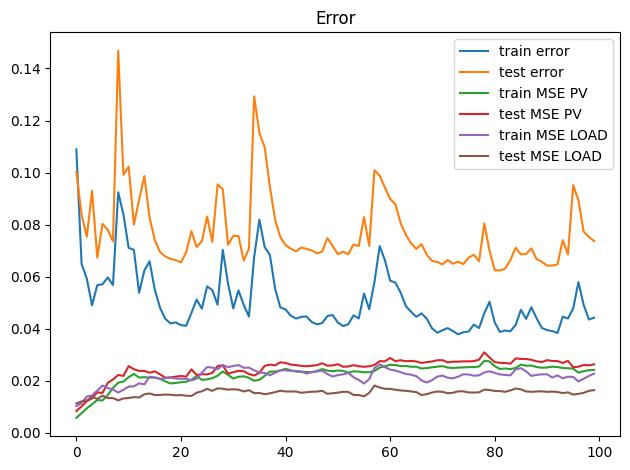

In [26]:
# Train / Finetune the LSTM-CVX model
start = time.time()
state_dicts_lstm_cvx, best_lstm_cvx = trainer_2.fit(verbose=2)
timings['LSTM-CVX'] = time.time() - start
best_epoch['LSTM-CVX'] = best_lstm_cvx

In [28]:
# Load the best dictionaries
lstm_cvx_opt.load_state_dict(state_dicts_lstm_cvx[best_lstm_cvx])

<All keys matched successfully>

In [35]:
pv_test_opt, load_test_opt, opt_output = lstm_cvx_opt(X_test_lstm_cvx[0,:,[0,2,3,4]].to(device),
             X_test_lstm_cvx[0,:,[1,3,4]].to(device),
             X_test_lstm_cvx[0,:,5].to(device),
             X_test_lstm_cvx[0,:,6].to(device),
             X_test_lstm_cvx[0,-1,7].to(device))

In [37]:
pv_test = lstm_pv(X_test_lstm_cvx[0,:,[0,2,3,4]].to(device))
load_test = lstm_load(X_test_lstm_cvx[0,:,[1,3,4]].to(device))

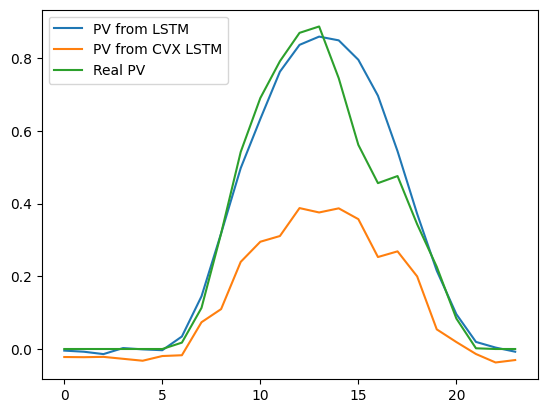

In [123]:
plt.plot(pv_test.cpu().detach(), label='PV from LSTM')
plt.plot(pv_test_opt.cpu().detach(), label='PV from CVX LSTM')
plt.plot(y_test_lstm_cvx[0,:,0].cpu().detach(), label='Real PV')

plt.legend()
plt.show()

In [125]:
cvx_test = cvx_real(rescale(pv_test_opt,scalers_opt[-2]).to(device),            # PV
                    rescale(load_test_opt,scalers_opt[-1]).to(device),
                    X_test_lstm_cvx[0,-hours:,-3].to(device),
                    X_test_lstm_cvx[0,-hours:,-2].to(device),
                    X_test_lstm_cvx[0,-1,-1].to(device))

cvx_test_correct = cvx_post(rescale(y_test_lstm_cvx[0,:,0],scalers_opt[-2]).to(device),            # PV
                            rescale(y_test_lstm_cvx[0,:,1],scalers_opt[-1]).to(device),
                            X_test_lstm_cvx[0,-hours:,-3].to(device),
                            X_test_lstm_cvx[0,-hours:,-2].to(device),
                            X_test_lstm_cvx[0,-1,-1].to(device),
                            cvx_test[-2],
                            cvx_test[-1])

offtake_cost_cvx = cvx_test_correct[0] * X_test_lstm_cvx[0,-hours:,-3].to(device)
injection_profit_cvx = cvx_test_correct[1] * X_test_lstm_cvx[0,-hours:,-2].to(device)

tensor(0.2224, device='cuda:0', grad_fn=<SumBackward0>)

In [131]:
lstm_test = cvx_real(rescale(pv_test,scalers_opt[-2]).to(device),            # PV
                    rescale(load_test,scalers_opt[-1]).to(device),
                    X_test_lstm_cvx[0,-hours:,-3].to(device),
                    X_test_lstm_cvx[0,-hours:,-2].to(device),
                    X_test_lstm_cvx[0,-1,-1].to(device))

lstm_test_correct = cvx_post(rescale(y_test_lstm_cvx[0,:,0],scalers_opt[-2]).to(device),            # PV
                            rescale(y_test_lstm_cvx[0,:,1],scalers_opt[-1]).to(device),
                            X_test_lstm_cvx[0,-hours:,-3].to(device),
                            X_test_lstm_cvx[0,-hours:,-2].to(device),
                            X_test_lstm_cvx[0,-1,-1].to(device),
                            lstm_test[-2],
                            lstm_test[-1])

offtake_cost_lstm = lstm_test_correct[0] * X_test_lstm_cvx[0,-hours:,-3].to(device)
injection_profit_lstm = lstm_test_correct[1] * X_test_lstm_cvx[0,-hours:,-2].to(device)

In [132]:
torch.sum(offtake_cost_cvx - injection_profit_cvx).cpu().detach(), torch.sum(offtake_cost_lstm - injection_profit_lstm).cpu().detach(), y_test_lstm_cvx[0,-1,2]

(tensor(0.2224), tensor(0.2619), tensor(0.1442))